In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Charger le CSV
df = pd.read_csv("../data/dataset_selection.csv")

# Aperçu du dataset
print("Aperçu du dataset :")
print(df.head())

print(f"\nNombre total d'images : {len(df)}")

# Répartition des labels
class_counts = df['label'].value_counts()
print("\nRépartition des labels :")
print(class_counts)

Aperçu du dataset :
                                                path     label
0  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
1  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
2  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome
3  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
4  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome

Nombre total d'images : 7796

Répartition des labels :
label
glaucome    1949
mda         1949
diabete     1949
normaux     1949
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df,
    test_size=0.1,
    stratify=df['label'],
    random_state=42
)

print("Tailles des splits :")
print(f"Train : {len(df_train)}")
print(f"Test : {len(df_test)}")

# Mapping label -> id
classes = sorted(df['label'].unique().tolist())
label_to_id = {c: i for i, c in enumerate(classes)}
print(f"\nClasses : {classes}")

Tailles des splits :
Train : 7016
Test : 780

Classes : ['diabete', 'glaucome', 'mda', 'normaux']


In [3]:
# Fonction pour enlever les bords noirs
def crop_black_border(img, thr=10, pad=10):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    mask = gray > thr
    if not mask.any():
        return img
    
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0] - 1, y1 + pad)
    x1 = min(img.shape[1] - 1, x1 + pad)
    
    return img[y0:y1+1, x0:x1+1]

def load_image(path, size=(128, 128)):
    img = cv2.imread(path)
    if img is None:
        return None
    img = crop_black_border(img, thr=10, pad=10)
    img = cv2.resize(img, size)
    return img

def augment_image(img):
    aug = []
    h, w = img.shape[:2]
    for angle in [-15, 15]:
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        aug.append(cv2.warpAffine(img, M, (w, h)))
    aug.append(cv2.flip(img, 1))   # flip horizontal
    aug.append(cv2.flip(img, 0))   # flip vertical
    aug.append(np.clip(img.astype(np.float32) * 1.2 - 15, 0, 255).astype(np.uint8))
    return aug

print("Fonctions de prétraitement définies ✓")

Fonctions de prétraitement définies ✓


In [4]:
from skimage.feature import hog

def extract_hog_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )
    return features.astype(np.float32)

def extract_pixel_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.flatten().astype(np.float32) / 255.0

print("Fonctions d'extraction de features définies ✓")
print(f"HOG sur image 128x128 donne {extract_hog_features(np.zeros((128, 128, 3), dtype=np.uint8)).shape[0]} features")
print(f"Pixels aplatis sur image 128x128 donne {128*128} features")

Fonctions d'extraction de features définies ✓
HOG sur image 128x128 donne 8100 features
Pixels aplatis sur image 128x128 donne 16384 features


In [5]:
def extract_all_features(df_subset, extract_func, augment=False):
    features = []
    labels = []
    valid_indices = []
    
    for idx, row in tqdm(df_subset.iterrows(), total=len(df_subset)):
        img = load_image(row['path'])
        if img is None:
            continue
        
        features.append(extract_func(img))
        labels.append(label_to_id[row['label']])
        valid_indices.append(idx)
        if augment:
            for aug_img in augment_image(img):
                features.append(extract_func(aug_img))
                labels.append(label_to_id[row['label']])
                valid_indices.append(idx)
    
    return np.array(features), np.array(labels), valid_indices

print("Extraction des features pixels (pour PCA)...")
X_train_pixels, y_train, _ = extract_all_features(df_train, extract_pixel_features, augment=True)
X_test_pixels, y_test, _ = extract_all_features(df_test, extract_pixel_features)

print(f"\nShape X_train_pixels: {X_train_pixels.shape}  (x6 avec augmentation)")
print(f"Shape X_test_pixels: {X_test_pixels.shape}")

Extraction des features pixels (pour PCA)...


  0%|          | 6/7016 [00:00<10:31, 11.10it/s][ WARN:0@6.002] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@6.002] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  2%|▏         | 162/7016 [00:09<04:38, 24.58it/s][ WARN:0@14.568] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@14.568] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  6%|▋         | 454/7016 [00:22<05:20, 20.44it/s][ WARN:0@28.352] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@28.352] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
 11%|█▏        | 801/7016 [00:38<04:59, 20.73it/s][ WARN:0@44.467] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirector


Shape X_train_pixels: (42096, 16384)  (x6 avec augmentation)
Shape X_test_pixels: (780, 16384)


In [6]:
print("Extraction des features HOG...")
X_train_hog, _, _ = extract_all_features(df_train, extract_hog_features, augment=True)
X_test_hog, _, _ = extract_all_features(df_test, extract_hog_features)

print(f"\nShape X_train_hog: {X_train_hog.shape}  (x6 avec augmentation)")
print(f"Shape X_test_hog: {X_test_hog.shape}")

Extraction des features HOG...


  0%|          | 5/7016 [00:00<07:13, 16.16it/s][ WARN:0@375.071] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@375.071] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  2%|▏         | 160/7016 [00:11<07:33, 15.12it/s][ WARN:0@385.880] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@385.880] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  6%|▋         | 455/7016 [00:30<06:44, 16.24it/s][ WARN:0@405.228] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@405.228] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
 11%|█▏        | 802/7016 [00:53<07:26, 13.91it/s][ WARN:0@428.219] global grfmt_tiff.cpp:122 TIFF_Warning TIFFRea


Shape X_train_hog: (42096, 8100)  (x6 avec augmentation)
Shape X_test_hog: (780, 8100)


In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_pixels = StandardScaler()
X_train_pixels_scaled = scaler_pixels.fit_transform(X_train_pixels).astype(np.float32)
X_test_pixels_scaled  = scaler_pixels.transform(X_test_pixels).astype(np.float32)
del X_train_pixels, X_test_pixels

print(f"Shape X_train_pixels_scaled: {X_train_pixels_scaled.shape}  float32")
print("PCA sera testée avec différents n_components dans le RandomizedSearchCV")

Shape X_train_pixels_scaled: (42096, 16384)  float32
PCA sera testée avec différents n_components dans le RandomizedSearchCV


In [8]:
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog).astype(np.float32)
X_test_hog_scaled  = scaler_hog.transform(X_test_hog).astype(np.float32)
del X_train_hog, X_test_hog

n_pixel_features = X_train_pixels_scaled.shape[1]
n_hog_features   = X_train_hog_scaled.shape[1]

print(f"X_train_pixels_scaled : {X_train_pixels_scaled.shape}  float32")
print(f"X_train_hog_scaled    : {X_train_hog_scaled.shape}  float32")

X_train_pixels_scaled : (42096, 16384)  float32
X_train_hog_scaled    : (42096, 8100)  float32


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, ShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 19, 23, 31, 51, 75],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}

pca_components = [30, 50, 75, 100, 125, 150]

cv_split = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

results = {}

print("Paramètres KNN à tester:")
for key, values in knn_params.items():
    print(f"  {key}: {values}")
print(f"\nComposantes PCA à tester: {pca_components}")
print("\nNote: n_neighbors évite les multiples de 4 pour empêcher les égalités")
print(f"      (4 classes → vote à égalité si k est multiple de 4)")

Paramètres KNN à tester:
  n_neighbors: [3, 5, 7, 9, 11, 13, 15, 19, 23, 31, 51, 75]
  weights: ['uniform', 'distance']
  metric: ['euclidean', 'manhattan']

Composantes PCA à tester: [30, 50, 75, 100, 125, 150]

Note: n_neighbors évite les multiples de 4 pour empêcher les égalités
      (4 classes → vote à égalité si k est multiple de 4)


RandomizedSearch pour: PCA
Fitting 1 folds for each of 150 candidates, totalling 150 fits

Meilleurs paramètres: {'pca__n_components': 30, 'knn__weights': 'uniform', 'knn__n_neighbors': 3, 'knn__metric': 'manhattan'}
Meilleur score val: 0.8757

 Métrique                 Score
--------------------------------
 Test Accuracy           0.7372
 Balanced Acc            0.7372
 Precision               0.7326
 Recall                  0.7372
 F1 Score                0.7328


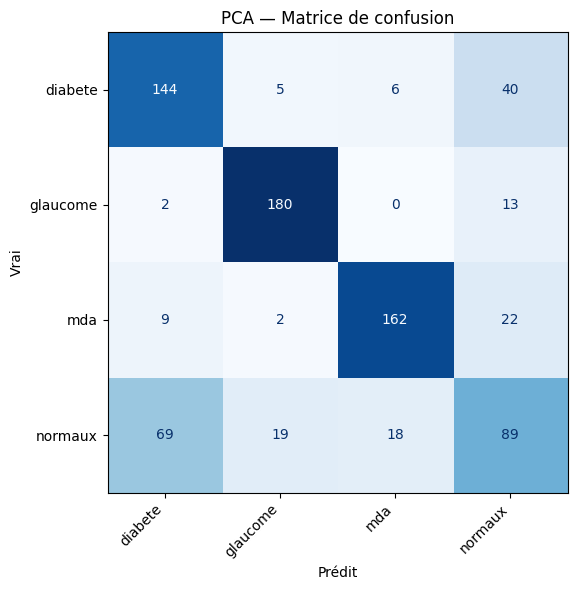

In [10]:
print("="*60)
print("RandomizedSearch pour: PCA")
print("="*60)

pipe_pca = Pipeline([
    ('pca', PCA(random_state=42)),
    ('knn', KNeighborsClassifier(algorithm='ball_tree', n_jobs=-1))
])
param_grid_pca = {
    'pca__n_components': pca_components,
    **{f'knn__{k}': v for k, v in knn_params.items()}
}
grid_pca = RandomizedSearchCV(pipe_pca, param_grid_pca,
    n_iter=150, cv=cv_split, scoring='accuracy',
    n_jobs=2, verbose=1, random_state=42)
grid_pca.fit(X_train_pixels_scaled, y_train)
print(f'\nMeilleurs paramètres: {grid_pca.best_params_}')
print(f'Meilleur score val: {grid_pca.best_score_:.4f}')
results['PCA'] = {'best_model': grid_pca.best_estimator_, 'best_params': grid_pca.best_params_,
    'best_val_score': grid_pca.best_score_, 'X_test': X_test_pixels_scaled}

# --- Résultats test ---
_y_pred = grid_pca.best_estimator_.predict(X_test_pixels_scaled)
_acc  = accuracy_score(y_test, _y_pred)
_bacc = balanced_accuracy_score(y_test, _y_pred)
_prec = precision_score(y_test, _y_pred, average='macro', zero_division=0)
_rec  = recall_score(y_test, _y_pred, average='macro', zero_division=0)
_f1   = f1_score(y_test, _y_pred, average='macro', zero_division=0)
print(f"\n{' Métrique':<22} {'Score':>8}")
print(f"{'-'*32}")
print(f"{' Test Accuracy':<22} {_acc:>8.4f}")
print(f"{' Balanced Acc':<22} {_bacc:>8.4f}")
print(f"{' Precision':<22} {_prec:>8.4f}")
print(f"{' Recall':<22} {_rec:>8.4f}")
print(f"{' F1 Score':<22} {_f1:>8.4f}")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, _y_pred, labels=list(range(len(classes)))),
    display_labels=classes).plot(ax=ax, values_format='d', cmap='Blues', colorbar=False)
ax.set_title("PCA — Matrice de confusion"); ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right'); plt.tight_layout(); plt.show()
results['PCA']['y_pred'] = _y_pred
results['PCA']['test_accuracy'] = _acc
results['PCA']['test_balanced_accuracy'] = _bacc
results['PCA']['test_f1'] = _f1

RandomizedSearch pour: HOG
Fitting 1 folds for each of 48 candidates, totalling 48 fits

Meilleurs paramètres: {'weights': 'distance', 'n_neighbors': 3, 'metric': 'manhattan'}
Meilleur score val: 0.8371

 Métrique                 Score
--------------------------------
 Test Accuracy           0.7705
 Balanced Acc            0.7705
 Precision               0.7811
 Recall                  0.7705
 F1 Score                0.7750


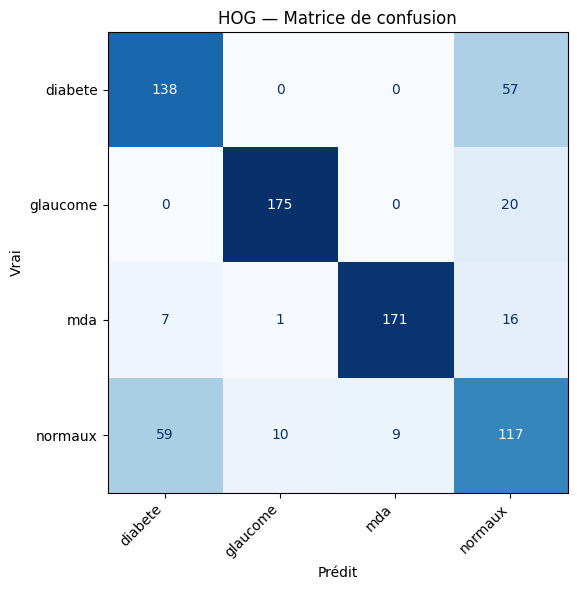

In [ ]:
print("="*60)
print("RandomizedSearch pour: HOG")
print("="*60)

knn_hog = KNeighborsClassifier(algorithm='ball_tree', n_jobs=-1)
grid_hog = RandomizedSearchCV(knn_hog, knn_params,
    n_iter=150, cv=cv_split, scoring='accuracy',
    n_jobs=2, verbose=1, random_state=42)
grid_hog.fit(X_train_hog_scaled, y_train)
print(f'\nMeilleurs paramètres: {grid_hog.best_params_}')
print(f'Meilleur score val: {grid_hog.best_score_:.4f}')
results['HOG'] = {'best_model': grid_hog.best_estimator_, 'best_params': grid_hog.best_params_,
    'best_val_score': grid_hog.best_score_, 'X_test': X_test_hog_scaled}

# --- Résultats test ---
_y_pred = grid_hog.best_estimator_.predict(X_test_hog_scaled)
_acc  = accuracy_score(y_test, _y_pred)
_bacc = balanced_accuracy_score(y_test, _y_pred)
_prec = precision_score(y_test, _y_pred, average='macro', zero_division=0)
_rec  = recall_score(y_test, _y_pred, average='macro', zero_division=0)
_f1   = f1_score(y_test, _y_pred, average='macro', zero_division=0)
print(f"\n{' Métrique':<22} {'Score':>8}")
print(f"{'-'*32}")
print(f"{' Test Accuracy':<22} {_acc:>8.4f}")
print(f"{' Balanced Acc':<22} {_bacc:>8.4f}")
print(f"{' Precision':<22} {_prec:>8.4f}")
print(f"{' Recall':<22} {_rec:>8.4f}")
print(f"{' F1 Score':<22} {_f1:>8.4f}")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, _y_pred, labels=list(range(len(classes)))),
    display_labels=classes).plot(ax=ax, values_format='d', cmap='Blues', colorbar=False)
ax.set_title("HOG — Matrice de confusion"); ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right'); plt.tight_layout(); plt.show()
results['HOG']['y_pred'] = _y_pred
results['HOG']['test_accuracy'] = _acc
results['HOG']['test_balanced_accuracy'] = _bacc
results['HOG']['test_f1'] = _f1

RandomizedSearch pour: PCA + HOG
PCA randomisé sur les pixels...
X_train_combined: (42096, 8225) (1.38 GB)
Fitting 1 folds for each of 48 candidates, totalling 48 fits
[CV] END knn__metric=euclidean, knn__n_neighbors=3, knn__weights=uniform; total time=37.5min
[CV] END knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total time=37.6min
[CV] END knn__metric=euclidean, knn__n_neighbors=5, knn__weights=uniform; total time=37.7min
[CV] END knn__metric=euclidean, knn__n_neighbors=5, knn__weights=distance; total time=37.7min
[CV] END knn__metric=euclidean, knn__n_neighbors=7, knn__weights=uniform; total time=37.8min
[CV] END knn__metric=euclidean, knn__n_neighbors=7, knn__weights=distance; total time=37.9min
[CV] END knn__metric=euclidean, knn__n_neighbors=9, knn__weights=uniform; total time=38.0min
[CV] END knn__metric=euclidean, knn__n_neighbors=9, knn__weights=distance; total time=38.0min
[CV] END knn__metric=euclidean, knn__n_neighbors=11, knn__weights=uniform; total tim

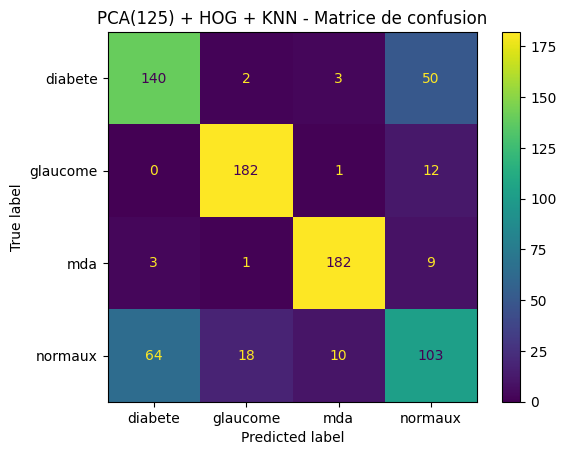

In [ ]:
import gc
from sklearn.decomposition import IncrementalPCA


print("="*60)
print("RandomizedSearch pour: PCA + HOG")
print("="*60)
print("PCA randomisé sur les pixels...")
from sklearn.decomposition import PCA

pca = PCA(n_components=125, svd_solver='randomized', random_state=42)
X_train_pca = pca.fit_transform(X_train_pixels_scaled).astype(np.float32)
X_test_pca = pca.transform(X_test_pixels_scaled).astype(np.float32)

# Purge des grosses matrices pixels (2.76 GB libérés)
del X_train_pixels_scaled, X_test_pixels_scaled
gc.collect()

# 2) Hstack PCA réduit + HOG
X_train_combined = np.hstack([X_train_pca, X_train_hog_scaled])
X_test_combined = np.hstack([X_test_pca, X_test_hog_scaled])
print(f"X_train_combined: {X_train_combined.shape} ({X_train_combined.nbytes/1e9:.2f} GB)")
# Purge du reste
del X_train_pca, X_test_pca, X_train_hog_scaled, X_test_hog_scaled
gc.collect()

# 3) GridSearch
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 19, 23, 31, 51, 75],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
}
cv_split = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

pipe_combined = Pipeline([
    ('knn', KNeighborsClassifier(algorithm='ball_tree', n_jobs=1))])

grid_combined = RandomizedSearchCV(
    pipe_combined,
    param_distributions={f'knn__{k}': v for k, v in knn_params.items()},
    n_iter=150, cv=cv_split, scoring='accuracy',
    n_jobs=1, verbose=2, random_state=42
)
grid_combined.fit(X_train_combined, y_train)

del X_train_combined
gc.collect()
y_pred = grid_combined.predict(X_test_combined)
print(f"\n {'Métrique':20s} {'Score':>8s}")
print("-"*28)
print(f" {'Test Accuracy':20s} {accuracy_score(y_test, y_pred):.4f}")
print(f" {'Balanced Acc':20s} {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f" {'Precision':20s} {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f" {'Recall':20s} {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f" {'F1 Score':20s} {f1_score(y_test, y_pred, average='macro'):.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='viridis', values_format='d')
plt.title("PCA + HOG + KNN - Matrice de confusion")
plt.show()

In [ ]:
import gc
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, ShuffleSplit

print("PCA 30 + HOG...")
pca = PCA(n_components=30, svd_solver='randomized', random_state=42)
X_train_pca = pca.fit_transform(X_train_pixels_scaled).astype(np.float32)
X_test_pca = pca.transform(X_test_pixels_scaled).astype(np.float32)
del X_train_pixels_scaled, X_test_pixels_scaled; gc.collect()
X_train_combined = np.hstack([X_train_pca, X_train_hog_scaled])
X_test_combined  = np.hstack([X_test_pca, X_test_hog_scaled])
del X_train_pca, X_test_pca, X_train_hog_scaled, X_test_hog_scaled; gc.collect()

print(f"Features: {X_train_combined.shape} ({X_train_combined.nbytes/1e9:.2f} GB)")

# KNN avec n_jobs=-1 DANS le modèle (threads, pas de dup mémoire)
knn = KNeighborsClassifier(algorithm='ball_tree', n_jobs=-1)

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 19, 23, 31, 51, 75],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
}
# n_jobs=1 dans le search = pas de dup mémoire
grid = RandomizedSearchCV(
    knn, knn_params, n_iter=60,
    cv=ShuffleSplit(n_splits=1, test_size=0.2, random_state=42),
    scoring='accuracy', n_jobs=1, verbose=2, random_state=42
)
grid.fit(X_train_combined, y_train)

print(f" {grid.best_params_} → {grid.best_score_:.4f}")
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Meilleur modèle
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test_combined)
y_score = best_knn.predict_proba(X_test_combined).max(axis=1)  # confiance

# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues',
                                         xticks_rotation=45, ax=ax)
ax.set_title(f'KNN (PCA30+HOG) — {grid.best_params_}\nAccuracy: {grid.best_score_:.2%}')
plt.tight_layout()
plt.show()

# Rapport détaillé
print("\nRapport par classe:")
print(classification_report(y_test, y_pred, target_names=classes))

PCA 30 + HOG...
Features: (42096, 8130) (1.37 GB)
Fitting 1 folds for each of 48 candidates, totalling 48 fits
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time= 7.7min
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time= 7.9min
[CV] END ...metric=euclidean, n_neighbors=5, weights=uniform; total time= 7.8min
[CV] END ..metric=euclidean, n_neighbors=5, weights=distance; total time= 7.7min
[CV] END ...metric=euclidean, n_neighbors=7, weights=uniform; total time= 7.7min
[CV] END ..metric=euclidean, n_neighbors=7, weights=distance; total time= 7.7min
[CV] END ...metric=euclidean, n_neighbors=9, weights=uniform; total time= 7.7min
[CV] END ..metric=euclidean, n_neighbors=9, weights=distance; total time= 7.7min
[CV] END ..metric=euclidean, n_neighbors=11, weights=uniform; total time= 8.3min
[CV] END .metric=euclidean, n_neighbors=11, weights=distance; total time= 8.2min
[CV] END ..metric=euclidean, n_neighbors=13, weights=uniform; total time= 7.8mi

In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
# Projection 2D des features combinées
pca_vis = PCA(n_components=2, random_state=42)
X_train_2d = pca_vis.fit_transform(X_train_combined)
X_test_2d = pca_vis.transform(X_test_combined)

# Ré-entraîne le meilleur KNN sur 2D pour les frontières
best_knn = grid.best_estimator_
knn_2d = KNeighborsClassifier(    n_neighbors=best_knn.n_neighbors,
    weights=best_knn.weights,
    metric=best_knn.metric,
    algorithm='ball_tree', n_jobs=-1
)
knn_2d.fit(X_train_2d, y_train)

# Grille de décision
x_min, x_max = X_train_2d[:,0].min()-1, X_train_2d[:,0].max()+1
y_min, y_max = X_train_2d[:,1].min()-1, X_train_2d[:,1].max()+1
h = (x_max - x_min) / 300
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot
classes = sorted(np.unique(y_train))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
cmap_bg = ListedColormap([c + '55' for c in colors[:len(classes)]])
cmap_pts = ListedColormap(colors[:len(classes)])

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.6)
ax.contour(xx, yy, Z, colors='white', linewidths=0.4, alpha=0.5)
ax.scatter(X_test_2d[:,0], X_test_2d[:,1], c=y_test, cmap=cmap_pts,
           edgecolors='k', linewidths=0.4, s=15, alpha=0.85)
ax.legend(handles=[Line2D([0],[0], marker='o', color='w',
           markerfacecolor=colors[i], markersize=8, label=c)
           for i, c in enumerate(classes)], loc='best')
ax.set_title(f'KNN (PCA30+HOG) → PCA 2D\n'
             f'k={best_knn.n_neighbors}, weights={best_knn.weights}, metric={best_knn.metric}')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

NameError: name 'X_train_pca' is not defined